# Calculating correlation function & correlation length from random process data

This code demonstrates how a correlation function and the associated correlation length is calculated given a vector of data representing a sample of a one-dimensional random process. You might like to visualize vectors like  acceleration vs. time in an earthquake, or as stock market value vs. time. For the purposes of demonstration, we will first generate a random process ourselves, and then we will analyze this data to determine the correlation function/length. This will allow us to compare the correlation function estimated from the data to a known underlying correlation function that was used to generate the data. 

# Step 1: Import the necessary packages, initialize the random process, and set input parameters
First, we need to import the numpy packages that will be used subsequently in this code. Then we identify the length of the specimen and the number of points at which the random process will be available. You can leave these as the values listed below. The simulated sample is a function of time, so we also initialize the time vector, with N1+1 evenly spaced points between 0 and sample length L1, assumed here to be 10. 

In [1]:
# Import packages
import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import eig

# Define input parameters
L1=10 #Length of the process
N1=1000 #Number of points on the process

# Initialize the time vector
t=np.linspace(0,L1,N1+1)
dt=t[2]-t[1]

# Step 2: Generate data

The following code generates a single sample of a stationary 1D Gaussian random process with mean 0. Later in the course, we will study the details of how we generate this data via simulation based on a given correlation function. For now you can take it as a given, that the code gives you a function based on a pre-specified correlation function. We will treat this as our data. Don't worry if you don't understand all of the code in this section generating data, since we will come back to this later. The advantage to simulating our data, rather than using data from some experiment, is that we have a benchmark to determine how well we have done with our estimate of the correlation function. 

The correlation function that we will use here is $B(\tau)=\sigma_X^2b^2/(b^2+\tau^2)$. One parameter we can control is b, which has some relationship to the correlation length. You will simulate a few different samples with different values of b, to see if you can guess how b might relate to correlation length. 

## Define function to generate the covariance matrix

In [2]:
def covmat (b,N,L,S2):

# Set up a vector of lags from -N to N
    lags=np.divide(np.multiply(np.arange(-N,N+1),L),N)

# Generate a vector acovvec containing the covariance function corresponding to each value listed in the vector lags
    #numerator of the correlation function
    bvec=np.multiply(np.power(b,2),(2*N1+1)*[1])
    #denom=b1vec+np.power(lags,2)
    acorvec=np.divide(bvec,(bvec+np.power(lags,2)))
    #multiply all by the variance of the random process - from correlation function to covariance function
    acovvec=np.multiply(acorvec,S2)
    
# Generate a matrix acovmat containing the covariance matrix describing the random process at all values in lags
    acovmat=acovvec.reshape(1,2*N+1)
    # Each column of the covariance matrix will be the covariance vector shifted by one place from the previous 
    # column. First, initialize a running vector tmpshftacov to start as the covariance vector acovvec, 
    # and also initialize shftacov to be the same type as acovvec.
    tmpshftacov=acovvec
    shftacov = np.empty_like(acovvec)
    # Loop over 0:N and shift all the elements in vector shftacov by 1, then append this vector onto the matrix acovmat
    # Make all the elements before the shift equal to 0
    for l in np.arange(N): 
        shftacov[:1] = 0
        shftacov[1:] = tmpshftacov[:-1]
        acovmat=np.append(acovmat, shftacov.reshape(1, 2*N+1), axis=0)
        tmpshftacov=shftacov
    # Delete the columns that are all zeros, so acovmat is an (N+1)x(N+1) matrix
    acovmat=np.delete(acovmat,slice(0,N),axis=1)
    
    return acovmat

## Define function to generate a random process
This function generates a process with parameter b and variance Var, with N values at discrete, evenly spaced points over sample length L.  

In [3]:
def simulation(N,L,b,Var):
    # Generate the covariance matrix covmat
    acovmat=covmat(b,N1,L1,Var)
    # Perform an eigenvalue analysis of covmat, getting eval (eigenvalues) and evec (eigenvectors)
    eval,evec=eig(acovmat)
    # Generate independent random variables with variances eval
    zvals=np.multiply(np.random.normal(0,1,N+1),np.power(eval,.5))
    # Generate correlated random varaibles, multiplying zvals by eigenvectors evec
    xvals=np.matmul(evec,zvals)
    
    return np.real(xvals)


In [4]:
#Generate formatted plots of random process ff, as a function of t
def ranplot(tt,f,b):
    plt.plot(tt,f)
    plt.xlabel('time')
    plt.ylabel('random process f(time)')
    plottitle="b = {}".format(b)
    plt.title(plottitle)
    plt.show()




## Generate 3 sample processes with different values for parameter b
This code will generate 3 samples, based on 3 values of b that you input, with a fixed variance.  What appears to happen as you change b? (Be patient with the code, it might take a few minutes to generate these processes and plots for you.)

What is the first parameter b? 10
What is the second parameter b? 0.1
What is the third parameter b? 0.001


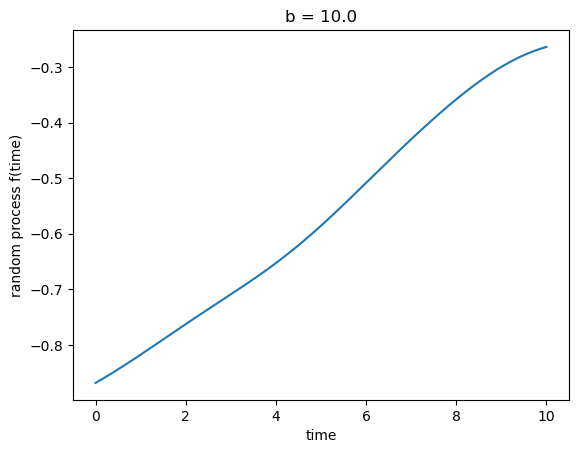

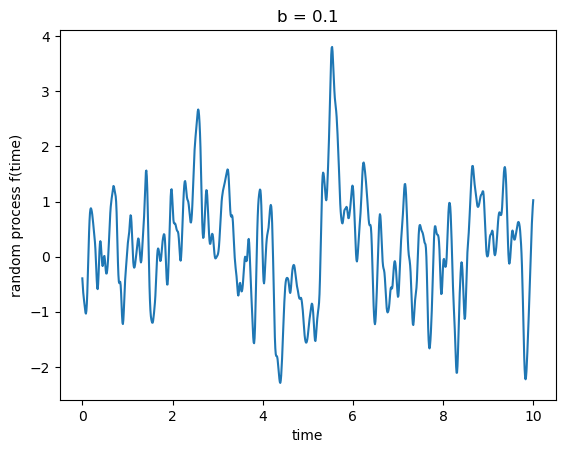

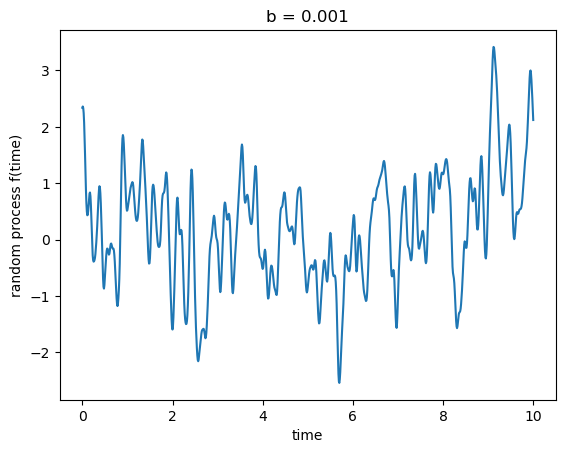

In [6]:
#Fix Var
Var=1
#Identify parameter b
b1 = float(input('What is the first parameter b? '))
b2 = float(input('What is the second parameter b? '))
b3 = float(input('What is the third parameter b? '))
#Generate sample processes f1, f2, f3 corresponding to b1, b2, b3
f1=simulation(N1,L1,b1,Var)
f2=simulation(N1,L1,b2,Var)
f3=simulation(N1,L1,b2,Var)
#generate plot of each f(t)
ranplot(t,f1,b1)
ranplot(t,f2,b2)
ranplot(t,f3,b3)

## Generate 10 sample processes to serve as data
This code will generate 10 samples, based on a single value of b that you input, again with a fixed variance. (Again, be patient with the code, this might take a minute to generate these processes.) 

In [16]:
# Set variance equal to 1 (can be modified, but will not ultimately affect the correlation function, which is 
#  normalized by the variance)
Var=1

# Identify parameter b
b1 = float(input('What is the parameter b? '))

# Generate 10 sample processes with parameter b
f1=simulation(N1,L1,b1,Var)
f2=simulation(N1,L1,b1,Var)
f3=simulation(N1,L1,b1,Var)
f4=simulation(N1,L1,b1,Var)
f5=simulation(N1,L1,b1,Var)
f6=simulation(N1,L1,b1,Var)
f7=simulation(N1,L1,b1,Var)
f8=simulation(N1,L1,b1,Var)
f9=simulation(N1,L1,b1,Var)
f10=simulation(N1,L1,b1,Var)

What is the parameter b? 0.001


# Step 3: Estimate the correlation functions from the data
Having established our data in Step 2 (10 sample random processes with correlation parameter b defined by the user), we will define a function that calculates the sample correlation functions associated with each of these 10 sample random processes. The process follows the discussion in our class video. First, it is convenient to define a function that will calculate and plot the correlation function.

In [17]:
def corfun (ff,N,dt,b):
    # Function to calculate and plot the correlation function of sample process ff, which is an N-value vector
    # Output vector gives the correlation function: entry acorr[l] is the correlation between values 
    #  in the sample process vector that are l entries apart
    
    # Set up a vector of lags from 0 to N
    lags=range(N)

    # Generate an initialized correlation function vector populated with zeros
    acorr = N * [0]

    # Go through lag components one-by-one
    for l in lags:
        c1 = 1 # Self correlation 

        if (l > 0):
            c2=np.corrcoef(ff[l:],ff[:-l]) #Find correlation matrix between ff(0:N-l) and ff(l:N)
            c1=c2[0,1] #Select off-diagonal entry of this correlation matrix
        acorr[l] = c1 #Place c1 in the l entry of vector acorr
        
    # Calculate mean and variance of sample ff
    m=np.mean(ff)
    v=np.mean(ff)
    
    # Calculate a vector of actual lags (multiply lags by dt)
    ll=lags*dt
    
    # Calculate exact correlation function
    bvec=np.multiply(np.power(b,2),N*[1])
    cfx=np.divide(bvec,(bvec+np.power(ll,2)))
    
    # Plot resulting correlation function
    plt.plot(ll,acorr)
    plt.plot(ll,cfx)
    plt.xlabel('lag')
    plt.ylabel('correlation function')
    plottitle="b = {}, mean = {}, var = {}".format(b,m,v)
    plt.title(plottitle)
    plt.show()
        
    return acorr

    

With these functions in hand, we can calculate and plot the correlation functions corresponding to each of the 5 random processes generated earlier. Noting that the correlation function we used in generating these processes is $B(\tau)=b^2/(b^2+\tau^2)$, this function (acorrex) is added to each plot, so that you can see a comparison with the exact underlying correlation function.

Sample 1


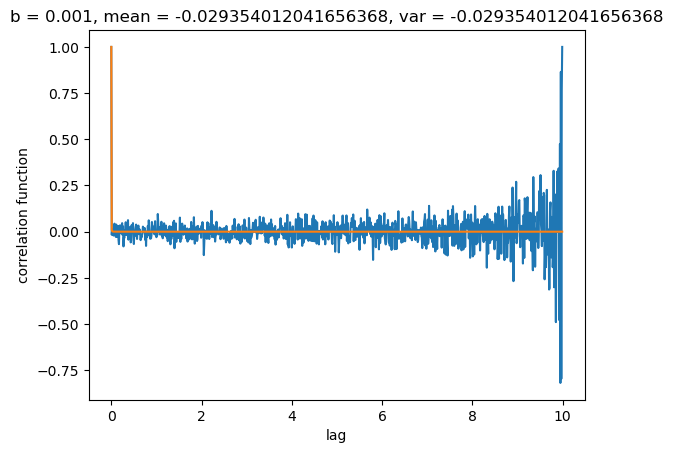

Sample 2


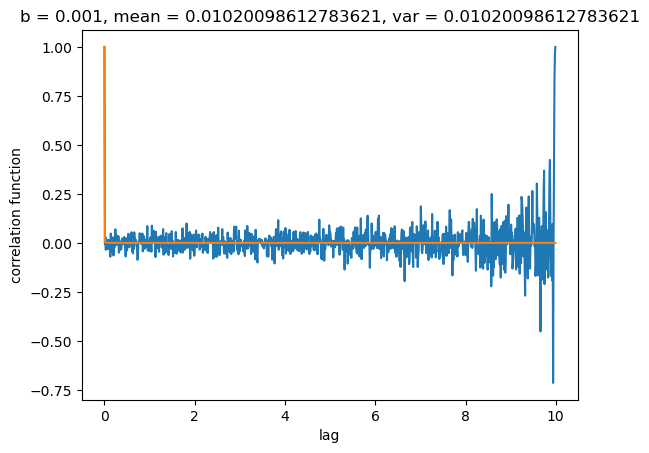

Sample 3


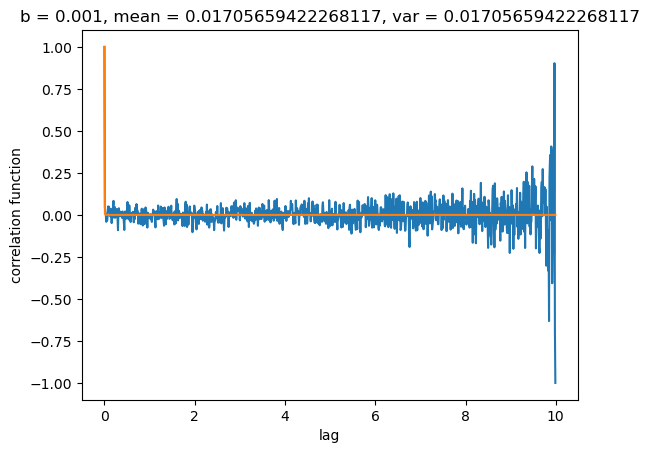

Sample 4


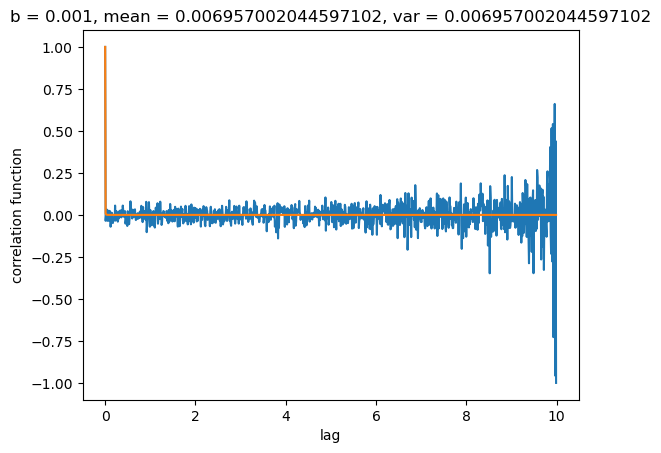

Sample 5


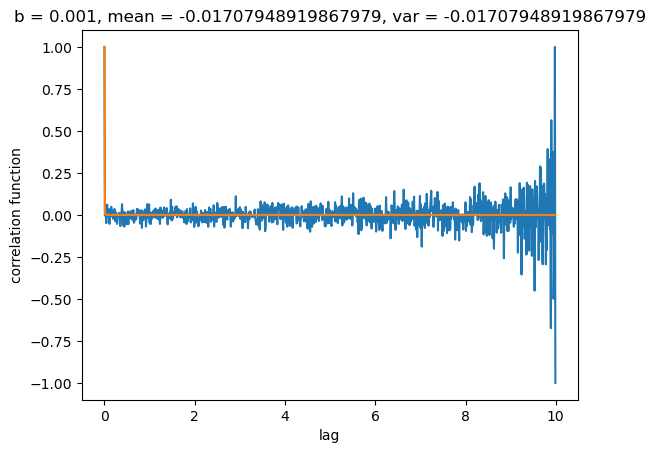

Sample 6


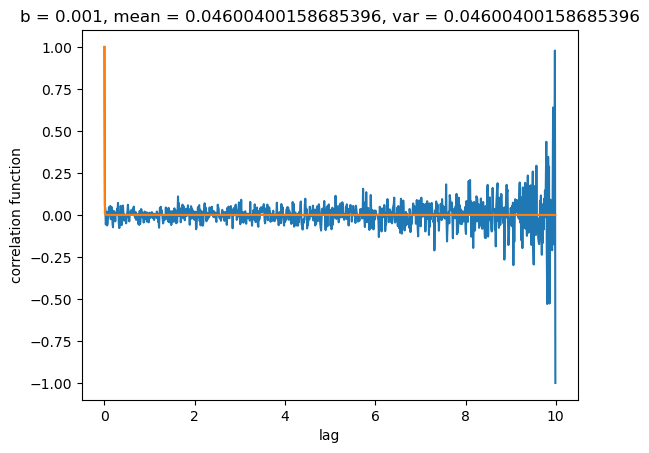

Sample 7


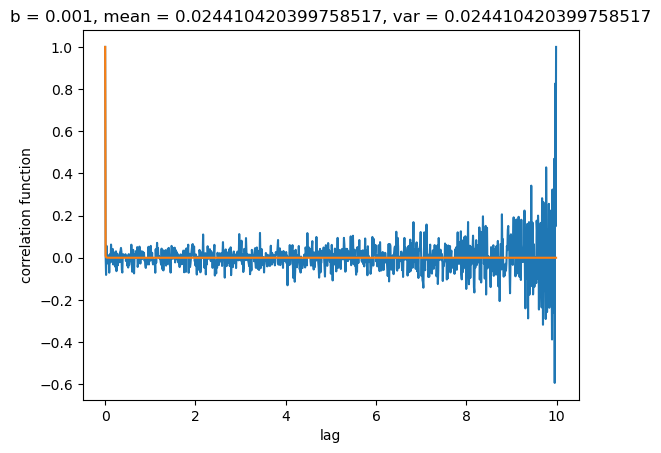

Sample 8


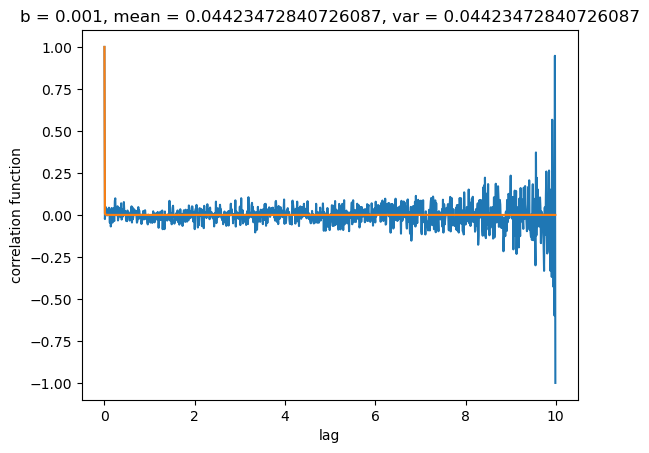

Sample 9


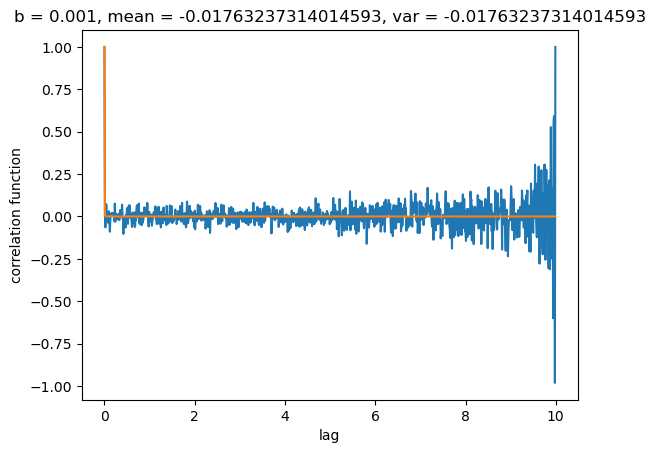

Sample 10


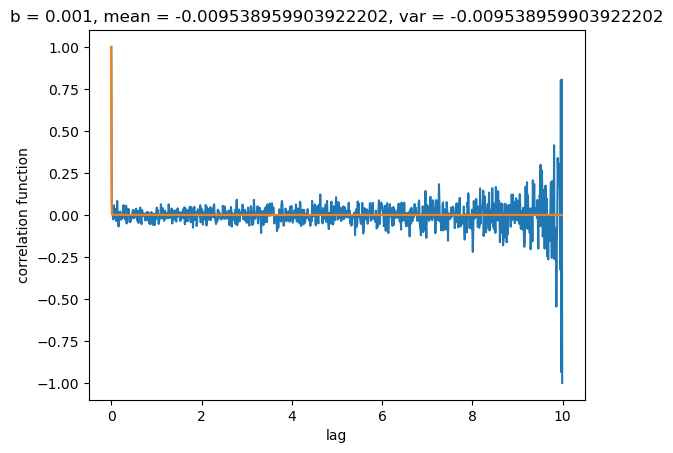

In [18]:
#calculate the correlation function of the first process
print('Sample 1')
acorr1=corfun(f1,N1,dt,b1)

#calculate the correlation function of the second process
print('Sample 2')
acorr2=corfun(f2,N1,dt,b1)

#calculate the correlation function of the first process
print('Sample 3')
acorr3=corfun(f3,N1,dt,b1)

#calculate the correlation function of the second process
print('Sample 4')
acorr4=corfun(f4,N1,dt,b1)

#calculate the correlation function of the first process
print('Sample 5')
acorr5=corfun(f5,N1,dt,b1)

#calculate the correlation function of the second process
print('Sample 6')
acorr6=corfun(f6,N1,dt,b1)

#calculate the correlation function of the first process
print('Sample 7')
acorr7=corfun(f7,N1,dt,b1)

#calculate the correlation function of the second process
print('Sample 8')
acorr8=corfun(f8,N1,dt,b1)

#calculate the correlation function of the first process
print('Sample 9')
acorr9=corfun(f9,N1,dt,b1)

#calculate the correlation function of the second process
print('Sample 10')
acorr10=corfun(f10,N1,dt,b1)

All the plots should show quite a bit of fluctuation around the exact correlation function. How does changing the parameter b1 change your results? 

If b1 is large (say 5, which is half the sample length), these estimates typically show a lot of error, even if they are quite smooth. If you look at the sample processes, you will see that each sample only contains a portion of one full fluctuation, so there is not enough data in each sample to make a meaningful estimate of the correlation function. If b1 is very small (say .005, which is smaller than the size of a time step in the sample random processes), then the estimate is poorly resolved in lags/time. There are enough fluctuations in the random process to get a meaningful sense of the statistics, but the function is not well resolved, because there is not enough data between points to develop a smooth correlation function. This lack of resolution leads to error in the estimate. This could be addressed by increasing the number of points in the sample, but that will come at the cost of slower calculations. 

Regardless of the value of b1 that you use here, you should see that there is noticeable error for the large values of the lag, which is the result of limited amounts of data available to compare data at large lag values. Sometimes the results can be improved by averaging over multiple samples, as follows.

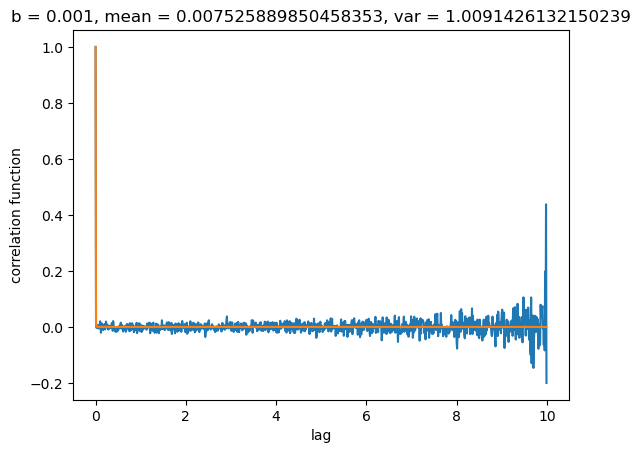

In [19]:
# Calculate the average mean, variance, correlation function from the 5 samples above
meanave=(np.mean(f1)+np.mean(f2)+np.mean(f3)+np.mean(f4)+np.mean(f5)+np.mean(f6)+np.mean(f7)+np.mean(f8)+np.mean(f9)+np.mean(f10))/10
varave=(np.var(f1)+np.var(f2)+np.var(f3)+np.var(f4)+np.var(f5)+np.var(f6)+np.var(f7)+np.var(f8)+np.var(f9)+np.var(f10))/10
acorrave=(np.array(acorr1)+np.array(acorr2)+np.array(acorr3)+np.array(acorr4)+np.array(acorr5)+np.array(acorr6)+np.array(acorr7)+np.array(acorr8)+np.array(acorr9)+np.array(acorr10))/10
# Calculate the exact correlation function
ll=range(N1)*dt
bvec=np.multiply(np.power(b1,2),N1*[1])
cfx=np.divide(bvec,(bvec+np.power(ll,2)))
# Plot the average correlation function and the exact correlation function
plt.plot(ll,acorrave)
plt.plot(ll,cfx)
plt.xlabel('lag')
plt.ylabel('correlation function')
plottitle="b = {}, mean = {}, var = {}".format(b1,meanave,varave)
plt.title(plottitle)
plt.show()

This plot should show less noise than each of the 10 sample correlation functions plotted earlier, but it certainly does not eliminate all of the noise, particularly at the large lag values. 

There are clear trade-offs here, in terms of the length of the sample L, the resolution dt, and the correlation parameter b1. For subsequent analyses, you might find it easier to go back and pick some intermediate value for b1, perhaps b1=0.1.

Now that we have the correlation functions estimated, we can move on to calculating the correlation length.
# Step 4: Calculate the correlation length
The correlation length is the integral of the correlation function from $-\infty$ to $\infty$. Given that there is significant noise in the estimated correlation function at large values of lag, integrating the estimated correlation functions over the entire domain of lags is likely to be unreliable. Below is a code to calculate this integral for 5 of the 10 sample processes we defined earlier, as well as the averaged correlation function. 

## Define function to calculate and print correlation length using full domain

In [20]:
def corlenfull(b1,acorr,lags,dt):

    #Approximate the correlation length by numerically integrating the correlation length over the entire domain
    corrlen=2*np.trapz(acorr,lags) #use trapezoidal integration, defined as trapz in numpy
    #Print the output correlation length
    print('The correlation length calculated from the full correlation function is')
    print(corrlen)
    print(' ')

In [21]:
#Print the value of b*pi
print('Underlying paramater b*pi is')
print(b1*np.pi)
print('------')
print(' ')

#Print the estimates of correlation length for each of the 5 sample processes
print('First Sample Process:')
corlenfull(b1,acorr1,ll,dt)

print('Second Sample Process:')
corlenfull(b1,acorr2,ll,dt)

print('Third Sample Process:')
corlenfull(b1,acorr3,ll,dt)

print('Fourth Sample Process:')
corlenfull(b1,acorr4,ll,dt)

print('Fifth Sample Process:')
corlenfull(b1,acorr5,ll,dt)

#Print the estimate of correlation length from the average of the 5 sample processes
print('Average Sample Process:')
corlenfull(b1,acorrave,ll,dt)

Underlying paramater b*pi is
0.0031415926535897933
------
 
First Sample Process:
The correlation length calculated from the full correlation function is
0.03250142302673569
 
Second Sample Process:
The correlation length calculated from the full correlation function is
0.05563872781084731
 
Third Sample Process:
The correlation length calculated from the full correlation function is
0.051470148399976746
 
Fourth Sample Process:
The correlation length calculated from the full correlation function is
0.006761927218637293
 
Fifth Sample Process:
The correlation length calculated from the full correlation function is
-0.0018238128921982837
 
Average Sample Process:
The correlation length calculated from the full correlation function is
0.019503842424940986
 


These results show significant variability, largely due to the noise at the higher values of lag. In some cases, you might even see a negative correlation length, which is physically unreasonable. It helps if we can avoid including the values at large lags. We can consider the correlation function over a limited range, for example from 0 to $\pi b$, as shown below for the averaged estimate of the correlation function. It is actually better to limit the integration to the range from 0 to $\pi b$. This provides a more reliable measure of the correlation length. Try running this a few times, to see how repeatable the results are. Based on these results, how do you think the parameter b relates to the correlation length? Are there any values of parameters b for which this analysis has more error than in other cases?

## Define function to calculate and print correlation length

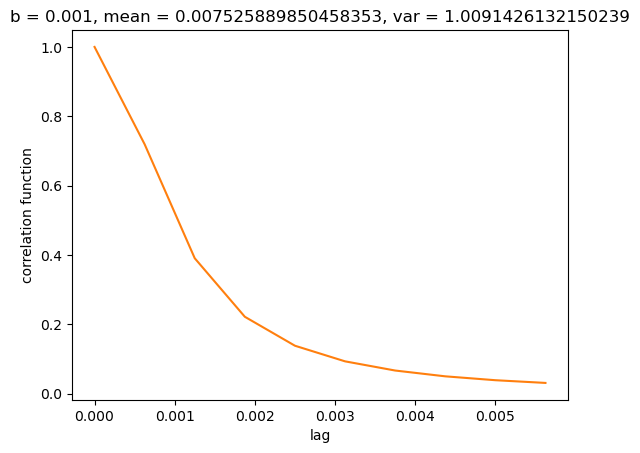

In [22]:
# Calculate the exact correlation function (increased resolution here by 16, just to ensure high-resolution on
#  the exact solution)
llx=range(N1*16)*dt/16
bvec=np.multiply(np.power(b1,2),16*N1*[1])
cfx=np.divide(bvec,(bvec+np.power(llx,2)))
cutoffx=int(np.round(2*b1*np.pi/dt*16)) 
# Plot the average correlation function and the exact correlation function
ll=range(N1)*dt
cutoff=int(np.round(2*b1*np.pi/dt)) 
plt.plot(ll[0:cutoff],acorrave[0:cutoff])
plt.plot(llx[0:cutoffx],cfx[0:cutoffx])
plt.xlabel('lag')
plt.ylabel('correlation function')
plottitle="b = {}, mean = {}, var = {}".format(b1,meanave,varave)
plt.title(plottitle)
plt.show()

In [23]:
def corlencut(b1,acorr,lags,dt):

    #Approximate the correlation length by numerically integrating the correlation length only from 0 to b*pi
    cutoff=int(np.round(b1*np.pi/dt)) #set a cutoff of b*pi for the integration domain
    print(cutoff)
    corrlencut=2*np.trapz(acorr[0:cutoff],lags[0:cutoff]) #use trapezoidal integration, defined as trapz in numpy

    print('The correlation length calculated from the correlation function over the range [0,b*pi] is')
    print(corrlencut)
    print(' ')

In [24]:
#Print the value of b*pi
print('Underlying paramater b*pi is')
print(b1*np.pi)
print('------')
print(' ')

#Print the estimates of correlation length for each of the 5 sample processes
print('First Sample Process:')
corlencut(b1,acorr1,ll,dt)

print('Second Sample Process:')
corlencut(b1,acorr2,ll,dt)

print('Third Sample Process:')
corlencut(b1,acorr3,ll,dt)

print('Fourth Sample Process:')
corlencut(b1,acorr4,ll,dt)

print('Fifth Sample Process:')
corlencut(b1,acorr5,ll,dt)

#Print the estimate of correlation length from the average of the 5 sample processes
print('Average Sample Process:')
corlencut(b1,acorrave,ll,dt)

Underlying paramater b*pi is
0.0031415926535897933
------
 
First Sample Process:
0
The correlation length calculated from the correlation function over the range [0,b*pi] is
0.0
 
Second Sample Process:
0
The correlation length calculated from the correlation function over the range [0,b*pi] is
0.0
 
Third Sample Process:
0
The correlation length calculated from the correlation function over the range [0,b*pi] is
0.0
 
Fourth Sample Process:
0
The correlation length calculated from the correlation function over the range [0,b*pi] is
0.0
 
Fifth Sample Process:
0
The correlation length calculated from the correlation function over the range [0,b*pi] is
0.0
 
Average Sample Process:
0
The correlation length calculated from the correlation function over the range [0,b*pi] is
0.0
 


Clearly, the estimate obtained by integrating over the limited domain of the correlation function reduces the noise associated with larger lags. However, this comes at the cost of introducing some bias. Considering the integral of the exact correlation function, there are small contributions to this integral from the values at large lags; however, this part of the domain is neglected in our estimate. In other words, while this estimate has the advantage of removing large noise, it introduces a bias towards underestimating the correlation length. 

Regardless of the bias described here, you might have observed that correlation length and $\pi b$ seem reasonably related, with our reasonable estimates of correlation length typically falling near but below $\pi b$. In fact, the true underlying correlation length is equal to $\pi b$. With infinite sampling and integration over the full domain of the correlation function, these would be equivalent. 